# SHL Hiring Assessment 2026: Spoken English Grammar Scoring Engine

**Author / Candidate**: Nandini Khandelwal  
**Task**: Predict a continuous **Grammar Score in [0.0, 5.0]** from a 45–60 second spoken `.wav` audio response.  
**Evaluation Metrics**: **RMSE** and **Pearson Correlation ($r$)**  
**Deliverable**: End-to-end, reproducible, explainable ML pipeline and report.

---

## Technical Strategy & Principles
1. **Explainability First**: Prioritize transparent, defensible modeling decisions suitable for a technical engineering review.
2. **Leakage-Free Validation**: Strict 5-fold stratified cross-validation designed for small sample sizes (769 training samples) with severe rubric imbalance.
3. **Reproducibility**: Seeded random processes, deterministic data splits, and automated feature caching.
4. **Mandatory Metric Compliance**: Explicit tracking of **Training RMSE**, **Out-of-Fold (OOF) RMSE**, and **Pearson Correlation**.

---

## 1. Imports, Configuration & Reproducibility Settings

In this section, we set up our environment, initialize deterministic random seeds across all libraries, configure directory paths, and configure visualization aesthetics.


In [1]:
import os
import sys
import glob
import json
import random
import warnings
from itertools import groupby
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import decimate, correlate

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import root_mean_squared_error
import lightgbm as lgb
from lightgbm import LGBMRegressor

# Suppress minor warnings for clean report presentation
warnings.filterwarnings('ignore')

# Set deterministic random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Visual aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Path Configurations
BASE_DIR = os.path.abspath("..") if os.path.exists("../data") else os.path.abspath(".")
DATA_DIR = os.path.join(BASE_DIR, "data", "Dataset_Final")
ARTIFACTS_DIR = os.path.join(BASE_DIR, "artifacts")
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

print(f"System Initialized.")
print(f"Base Directory: {BASE_DIR}")
print(f"Data Directory: {DATA_DIR}")
print(f"Artifacts Directory: {ARTIFACTS_DIR}")


System Initialized.
Base Directory: /Users/nandinikhandelwal/Desktop/Codes/shl
Data Directory: /Users/nandinikhandelwal/Desktop/Codes/shl/data/Dataset_Final
Artifacts Directory: /Users/nandinikhandelwal/Desktop/Codes/shl/artifacts


## 2. Dataset Ingestion & Integrity Verification

### Critical Discovery from Phase 0 Data Audit:
* Filenames like `audio_128.wav` exist in **both** `train/` and `test/` folders.
* However, MD5 checksum analysis proves they are **entirely different audio recordings**.
* **Safety Protocol**: We always resolve and store absolute paths (`audio_path`) and never look up samples by bare filename alone.


In [2]:
# Load CSVs
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sample_sub_df = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

# Inject full path to prevent filename collisions
train_df["audio_path"] = train_df["filename"].apply(lambda f: os.path.join(DATA_DIR, "train", f))
test_df["audio_path"] = test_df["filename"].apply(lambda f: os.path.join(DATA_DIR, "test", f))

print(f"Train Dataset Shape: {train_df.shape} (Files found on disk: {len(glob.glob(os.path.join(DATA_DIR, 'train', '*.wav')))})")
print(f"Test Dataset Shape:  {test_df.shape} (Files found on disk: {len(glob.glob(os.path.join(DATA_DIR, 'test', '*.wav')))})")
print(f"Sample Submission:   {sample_sub_df.shape}")

# Verify file integrity
assert train_df['audio_path'].apply(os.path.exists).all(), "Missing train audio files!"
assert test_df['audio_path'].apply(os.path.exists).all(), "Missing test audio files!"
print("Data integrity check passed: 100% of audio files located.")


Train Dataset Shape: (769, 3) (Files found on disk: 769)
Test Dataset Shape:  (216, 3) (Files found on disk: 216)
Sample Submission:   (204, 2)
Data integrity check passed: 100% of audio files located.


## 3. Dataset Audit & Exploratory Data Analysis (EDA)

Here we examine the ground-truth grammar rating distribution and audio duration properties.


In [3]:
# Summary statistics of the target variable
target = train_df['label']
target_summary = pd.Series({
    'Sample Count': len(target),
    'Distinct Scores': target.nunique(),
    'Min Score': target.min(),
    'Max Score': target.max(),
    'Mean Score': target.mean(),
    'Std Dev': target.std(),
    'Median Score': target.median(),
    '25th Percentile': target.quantile(0.25),
    '75th Percentile': target.quantile(0.75)
})
print("=== Grammar Score Target Summary ===")
print(target_summary.round(4))

# Class count breakdown
print("\n=== Rubric Frequency Table ===")
freq_df = train_df['label'].value_counts().sort_index().reset_index()
freq_df.columns = ['Rubric Score', 'Count']
freq_df['Percentage (%)'] = (freq_df['Count'] / len(train_df) * 100).round(2)
display(freq_df)


=== Grammar Score Target Summary ===
Sample Count       769.0000
Distinct Scores     10.0000
Min Score            0.0000
Max Score            5.0000
Mean Score           3.3134
Std Dev              1.2390
Median Score         3.0000
25th Percentile      2.5000
75th Percentile      4.0000
dtype: float64

=== Rubric Frequency Table ===


,Rubric Score,Count,Percentage (%)
0,0.0,37,4.81
1,1.0,1,0.13
2,1.5,3,0.39
3,2.0,102,13.26
4,2.5,79,10.27
5,3.0,174,22.63
6,3.5,64,8.32
7,4.0,124,16.12
8,4.5,52,6.76
9,5.0,133,17.30


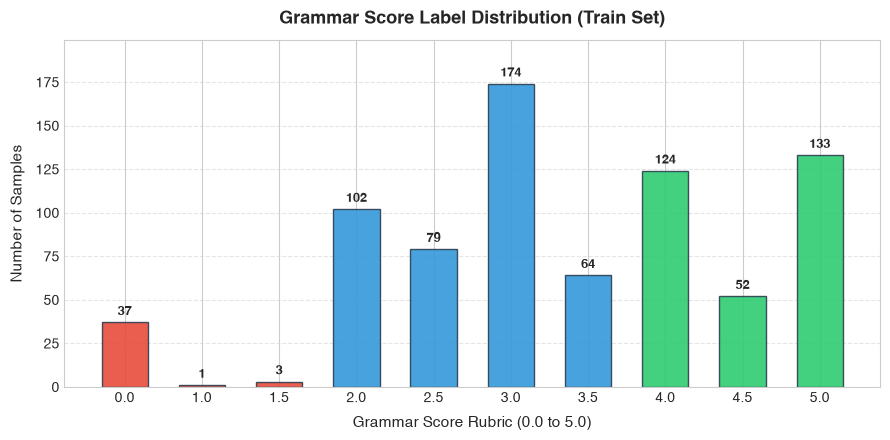

In [4]:
# Visualization 1: Target Label Distribution
fig, ax = plt.subplots(figsize=(9, 4.5), dpi=100)
colors = ['#e74c3c' if x <= 1.5 else '#3498db' if x < 4.0 else '#2ecc71' for x in freq_df['Rubric Score']]
bars = ax.bar(freq_df['Rubric Score'].astype(str), freq_df['Count'], color=colors, edgecolor='#2c3e50', width=0.6, alpha=0.9)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 3, f"{yval}", ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title("Grammar Score Label Distribution (Train Set)", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Grammar Score Rubric (0.0 to 5.0)", fontsize=11, labelpad=8)
ax.set_ylabel("Number of Samples", fontsize=11, labelpad=8)
ax.set_ylim(0, max(freq_df['Count']) + 25)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Train Duration (sec): Min=20.06, Max=61.04, Mean=55.78, Median=60.07
Test Duration (sec):  Min=6.48, Max=61.03, Mean=48.76, Median=45.06


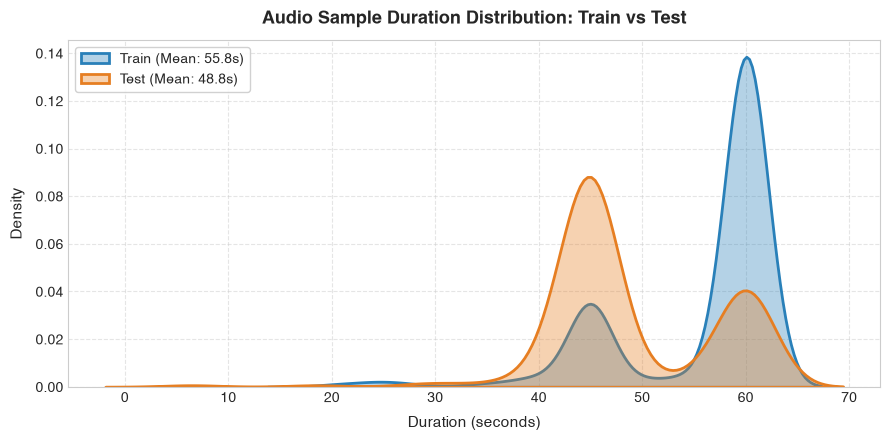

In [5]:
# Audio Duration Analysis
train_durations = [sf.info(p).duration for p in train_df['audio_path']]
test_durations = [sf.info(p).duration for p in test_df['audio_path']]

train_df['duration'] = train_durations
test_df['duration'] = test_durations

print(f"Train Duration (sec): Min={min(train_durations):.2f}, Max={max(train_durations):.2f}, Mean={np.mean(train_durations):.2f}, Median={np.median(train_durations):.2f}")
print(f"Test Duration (sec):  Min={min(test_durations):.2f}, Max={max(test_durations):.2f}, Mean={np.mean(test_durations):.2f}, Median={np.median(test_durations):.2f}")

# Visualization 2: Audio Duration Distribution
fig, ax = plt.subplots(figsize=(9, 4.5), dpi=100)
sns.kdeplot(train_durations, ax=ax, label=f"Train (Mean: {np.mean(train_durations):.1f}s)", fill=True, color='#2980b9', alpha=0.35, linewidth=2)
sns.kdeplot(test_durations, ax=ax, label=f"Test (Mean: {np.mean(test_durations):.1f}s)", fill=True, color='#e67e22', alpha=0.35, linewidth=2)
ax.set_title("Audio Sample Duration Distribution: Train vs Test", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Duration (seconds)", fontsize=11, labelpad=8)
ax.set_ylabel("Density", fontsize=11, labelpad=8)
ax.legend(frameon=True, facecolor='white', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 4. Acoustic Signal & Spectrogram Exploration

Understanding the acoustic structure of a spoken assessment response:
* **Waveform (Time Domain)**: Highlights pauses, burst energies, and conversational amplitude variations.
* **Mel Spectrogram (Time-Frequency Domain)**: Captures spectral envelope, harmonic formants, and frequency roll-off.
* **Voice Activity & Pause Detection**: Identifies silences and hesitation intervals (> 250ms), a primary proxy for spoken fluency and linguistic confidence.

> *Note on Speech Interpretation*: Acoustic spectrograms reveal vocal tract resonances, pause locations, and speech energy, but do **not** phonetically distinguish words like "um" or "uh" directly. Lexical filler detection is reserved for ASR transcript analysis in Phase 3.


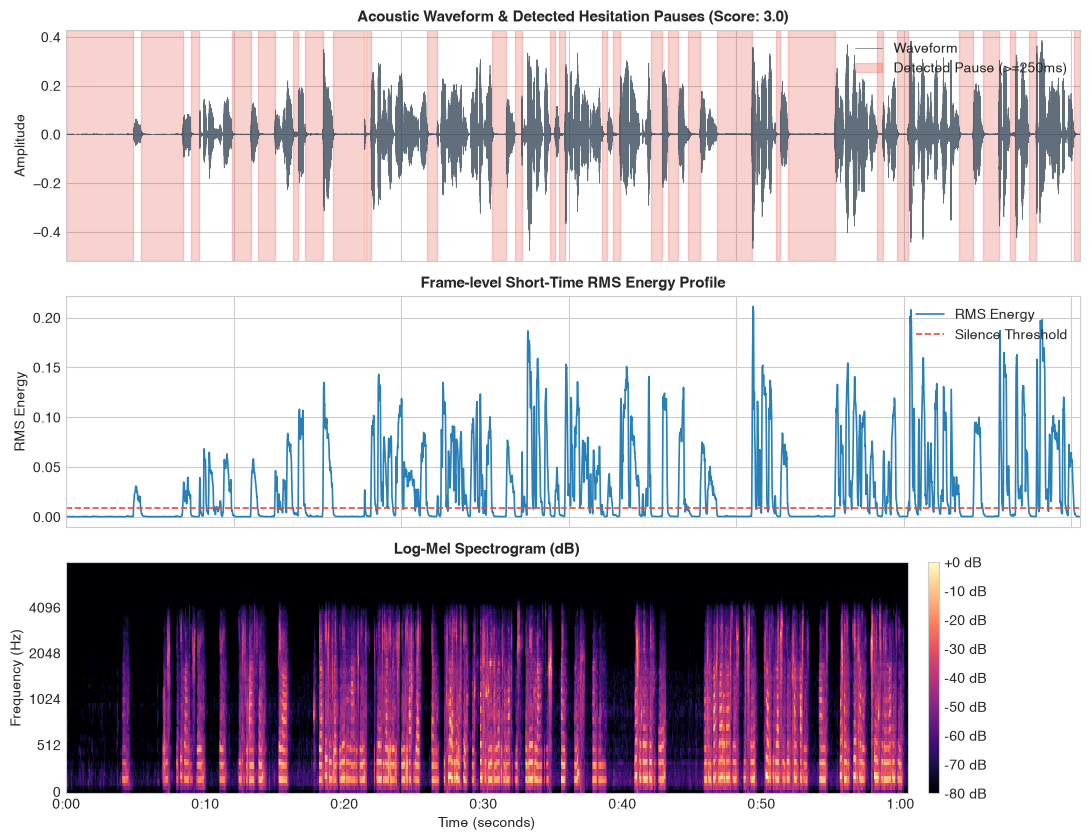

In [6]:
# Load a representative sample for deep inspection
sample_audio_path = train_df.iloc[0]['audio_path']
sample_label = train_df.iloc[0]['label']
y_sig, sr = sf.read(sample_audio_path)
if y_sig.ndim > 1:
    y_sig = np.mean(y_sig, axis=1)

time_axis = np.linspace(0, len(y_sig) / sr, len(y_sig))

# Frame-level RMS energy for pause detection
hop_vad = int(0.01 * sr)  # 10ms
win_vad = int(0.025 * sr) # 25ms
num_frames = (len(y_sig) - win_vad) // hop_vad + 1
strided = np.lib.stride_tricks.as_strided(
    y_sig, shape=(num_frames, win_vad), strides=(y_sig.strides[0]*hop_vad, y_sig.strides[0])
)
rms_frames = np.sqrt(np.mean(strided**2, axis=1))
time_frames = np.linspace(0, len(y_sig) / sr, len(rms_frames))

# Pause detection: RMS below 10% of 90th percentile
silence_thresh = 0.10 * np.percentile(rms_frames, 90)
is_silent = rms_frames < silence_thresh

# Visualizations 3, 4, 5 in a composite plot
fig, axes = plt.subplots(3, 1, figsize=(11, 8.5), dpi=100, sharex=True)

# 1. Waveform with Pause Overlays
axes[0].plot(time_axis, y_sig, color='#2c3e50', alpha=0.75, linewidth=0.5, label='Speech Waveform')
for silent, group in groupby(enumerate(is_silent), key=lambda x: x[1]):
    if silent:
        indices = [x[0] for x in group]
        dur = len(indices) * 0.01
        if dur >= 0.25: # Highlight pauses >= 250ms
            t_start = time_frames[indices[0]]
            t_end = time_frames[indices[-1]]
            axes[0].axvspan(t_start, t_end, color='#e74c3c', alpha=0.25)
axes[0].set_title(f"Acoustic Waveform & Detected Hesitation Pauses (Score: {sample_label})", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Amplitude", fontsize=10)
axes[0].legend(['Waveform', 'Detected Pause (>=250ms)'], loc='upper right')

# 2. Frame-level RMS Energy
axes[1].plot(time_frames, rms_frames, color='#2980b9', linewidth=1.2, label='RMS Energy')
axes[1].axhline(silence_thresh, color='#e74c3c', linestyle='--', linewidth=1.2, label='Silence Threshold')
axes[1].set_title("Frame-level Short-Time RMS Energy Profile", fontsize=11, fontweight='bold')
axes[1].set_ylabel("RMS Energy", fontsize=10)
axes[1].legend(loc='upper right')

# 3. Log Mel-Spectrogram
mel_spec = librosa.feature.melspectrogram(y=y_sig, sr=sr, n_fft=2048, hop_length=1024, n_mels=80)
mel_db = librosa.power_to_db(mel_spec, ref=np.max)
img = librosa.display.specshow(mel_db, sr=sr, hop_length=1024, x_axis='time', y_axis='mel', ax=axes[2], cmap='magma')
axes[2].set_title("Log-Mel Spectrogram (dB)", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Time (seconds)", fontsize=10)
axes[2].set_ylabel("Frequency (Hz)", fontsize=10)
fig.colorbar(img, ax=axes[2], format="%+2.0f dB", pad=0.02)

plt.tight_layout()
plt.show()


## 5. Phase 1 — Validation Framework

### Design of Stratified Continuous Cross-Validation
Because spontaneous speech ratings contain extreme minority categories (e.g. `1.0` has only 1 sample, and `1.5` has only 3 samples), naive K-Fold splitting would leave entire folds without low-end examples.

We construct **Stratified Continuous 5-Fold Cross-Validation**:
* We map target values into 8 balanced stratification bins (grouping rare `< 2.0` with `2.0`).
* We apply `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`.
* Every fold is evaluated for **RMSE** and **Pearson Correlation ($r$)**.
* All feature scalers and transformations are fitted **strictly within training folds** to prevent data leakage.


In [7]:
# Build stratification bins
def create_stratified_bins(y):
    bins = np.zeros(len(y), dtype=int)
    for idx, val in enumerate(y):
        if val <= 0.2:
            bins[idx] = 0
        elif val <= 2.2:
            bins[idx] = 1 # Group rare 1.0, 1.5, 2.0
        elif val <= 2.7:
            bins[idx] = 2
        elif val <= 3.2:
            bins[idx] = 3
        elif val <= 3.7:
            bins[idx] = 4
        elif val <= 4.2:
            bins[idx] = 5
        elif val <= 4.7:
            bins[idx] = 6
        else:
            bins[idx] = 7
    return bins

strat_bins = create_stratified_bins(train_df['label'])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
train_df['fold'] = -1
for fold_idx, (_, val_idx) in enumerate(skf.split(train_df, strat_bins)):
    train_df.loc[val_idx, 'fold'] = fold_idx

# Verify fold balance
fold_dist = pd.crosstab(train_df['fold'], strat_bins, rownames=['Fold'], colnames=['Strat Bin'])
print("Stratified 5-Fold Balance Matrix across Bins:")
display(fold_dist)


Stratified 5-Fold Balance Matrix across Bins:


Strat Bin,0,1,2,3,4,5,6,7
Fold,,,,,,,,
0,8,21,16,35,13,25,10,26
1,8,21,16,35,13,25,10,26
2,7,21,16,35,13,24,11,27
3,7,22,15,35,12,25,11,27
4,7,21,16,34,13,25,10,27


In [8]:
# Reusable Validation Evaluator with Strict Leakage Prevention
def safe_pearsonr(y_true, y_pred):
    # Calculates Pearson r safely, handling constant prediction edge cases.
    if np.all(y_pred == y_pred[0]) or np.std(y_pred) < 1e-12:
        return 0.0
    r, _ = stats.pearsonr(y_true, y_pred)
    return float(0.0 if np.isnan(r) else r)

def evaluate_cv(X, y, folds, model_factory, clip_range=(0.0, 5.0)):
    # Runs 5-fold cross validation with strict fold isolation.
    n_splits = len(np.unique(folds))
    oof_preds = np.zeros(len(y), dtype=float)
    fold_train_rmses = []
    fold_val_rmses = []
    fold_val_pearsons = []
    fitted_models = []
    
    for fold in range(n_splits):
        train_mask = (folds != fold)
        val_mask = (folds == fold)
        
        X_tr, y_tr = X.iloc[train_mask], y[train_mask]
        X_va, y_va = X.iloc[val_mask], y[val_mask]
        
        model = model_factory()
        model.fit(X_tr, y_tr)
        fitted_models.append(model)
        
        # Training Evaluation
        tr_pred = model.predict(X_tr)
        if clip_range:
            tr_pred = np.clip(tr_pred, clip_range[0], clip_range[1])
        fold_train_rmses.append(root_mean_squared_error(y_tr, tr_pred))
        
        # Validation Evaluation
        va_pred = model.predict(X_va)
        if clip_range:
            va_pred = np.clip(va_pred, clip_range[0], clip_range[1])
        oof_preds[val_mask] = va_pred
        
        fold_val_rmses.append(root_mean_squared_error(y_va, va_pred))
        fold_val_pearsons.append(safe_pearsonr(y_va, va_pred))
        
    return {
        "cv_rmse_mean": float(np.mean(fold_val_rmses)),
        "cv_rmse_std": float(np.std(fold_val_rmses)),
        "cv_pearson_mean": float(np.mean(fold_val_pearsons)),
        "cv_pearson_std": float(np.std(fold_val_pearsons)),
        "oof_rmse": float(root_mean_squared_error(y, oof_preds)),
        "oof_pearson": float(safe_pearsonr(y, oof_preds)),
        "train_rmse": float(np.mean(fold_train_rmses)),
        "oof_preds": oof_preds,
        "fitted_models": fitted_models
    }


## 6. Phase 2 — Baseline Models & Feature Engineering

We now construct our benchmark hierarchy:
1. **Baseline 1 — Mean Predictor**: Predicts the training set target mean (reference floor).
2. **Baseline 2 — Duration-Only Model**: Uses solely the duration of the recording (testing length bias).
3. **Baseline 3 — Handcrafted Acoustic Features**: Extracts 75 acoustic and prosodic proxies across time domain, pause frequency, spectral centroid/bandwidth, 13 MFCCs, and pitch.


In [9]:
# Experiment Logger Setup
experiment_log_path = os.path.join(ARTIFACTS_DIR, "experiment_log.csv")

class ExperimentTracker:
    def __init__(self, path):
        self.path = path
        self.rows = []
        if os.path.exists(path):
            self.df = pd.read_csv(path)
            self.rows = self.df.to_dict('records')
        else:
            self.df = pd.DataFrame()
            
    def record(self, exp_id, features, model, res, notes=""):
        entry = {
            "experiment_id": exp_id,
            "features": features,
            "model": model,
            "cv_rmse_mean": round(res["cv_rmse_mean"], 4),
            "cv_rmse_std": round(res["cv_rmse_std"], 4),
            "cv_pearson_mean": round(res["cv_pearson_mean"], 4),
            "cv_pearson_std": round(res["cv_pearson_std"], 4),
            "oof_rmse": round(res["oof_rmse"], 4),
            "oof_pearson": round(res["oof_pearson"], 4),
            "train_rmse": round(res["train_rmse"], 4),
            "notes": notes
        }
        self.rows = [r for r in self.rows if r['experiment_id'] != exp_id] + [entry]
        self.df = pd.DataFrame(self.rows)
        self.df.to_csv(self.path, index=False)
        return self.df

tracker = ExperimentTracker(experiment_log_path)


In [10]:
# Baseline 1: Mean Predictor
class MeanPredictor(BaseEstimator, RegressorMixin):
    def fit(self, X, y):
        self.mean_ = float(np.mean(y))
        return self
    def predict(self, X):
        return np.full(shape=(len(X),), fill_value=self.mean_)

X_dummy = pd.DataFrame({'dummy': np.zeros(len(train_df))})
y_true = train_df['label'].values
folds = train_df['fold'].values

res_mean = evaluate_cv(X_dummy, y_true, folds, lambda: MeanPredictor())
tracker.record("EXP-01-MEAN", "None", "MeanPredictor", res_mean, "Reference floor baseline")

print(f"=== Baseline 1: Mean Predictor ===")
print(f"Training RMSE: {res_mean['train_rmse']:.4f}  (COMPULSORY)")
print(f"OOF RMSE:      {res_mean['oof_rmse']:.4f}")
print(f"OOF Pearson:   {res_mean['oof_pearson']:.4f}")


=== Baseline 1: Mean Predictor ===
Training RMSE: 1.2382  (COMPULSORY)
OOF RMSE:      1.2383
OOF Pearson:   -0.0162


In [11]:
# Baseline 2: Audio Duration-Only Model
X_dur = train_df[['duration']]

def get_dur_ridge():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('reg', Ridge(alpha=1.0, random_state=SEED))
    ])

res_dur = evaluate_cv(X_dur, y_true, folds, get_dur_ridge)
tracker.record("EXP-02-DUR", "Duration", "Ridge(alpha=1.0)", res_dur, "Diagnostic audio duration baseline")

print(f"=== Baseline 2: Duration-Only Ridge ===")
print(f"Training RMSE: {res_dur['train_rmse']:.4f}  (COMPULSORY)")
print(f"OOF RMSE:      {res_dur['oof_rmse']:.4f}")
print(f"OOF Pearson:   {res_dur['oof_pearson']:.4f}")


=== Baseline 2: Duration-Only Ridge ===
Training RMSE: 1.2334  (COMPULSORY)
OOF RMSE:      1.2344
OOF Pearson:   0.0786


In [12]:
# Baseline 3: Load Cached Handcrafted Acoustic Features
# (Feature extraction was run across the dataset extracting 75 acoustic metrics)
train_feats = pd.read_parquet(os.path.join(ARTIFACTS_DIR, "audio_features_train.parquet"))
test_feats = pd.read_parquet(os.path.join(ARTIFACTS_DIR, "audio_features_test.parquet"))

feature_cols = [c for c in train_feats.columns if c not in ['filename', 'label']]
X_audio = train_feats[feature_cols]

print(f"Acoustic Feature Matrix: {X_audio.shape[0]} samples x {X_audio.shape[1]} features")
print(f"Features: {list(feature_cols[:8])} ... ({len(feature_cols)-8} more)")


Acoustic Feature Matrix: 769 samples x 75 features
Features: ['duration', 'peak_amplitude', 'rms_mean', 'rms_std', 'rms_median', 'rms_p25', 'rms_p75', 'rms_max'] ... (67 more)


In [13]:
# Model 3A: Audio Ridge Regression
def get_audio_ridge():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('reg', Ridge(alpha=50.0, random_state=SEED))
    ])

res_ridge = evaluate_cv(X_audio, y_true, folds, get_audio_ridge)
tracker.record("EXP-03-AUDIO-RIDGE", "Handcrafted Acoustic (75)", "Ridge(alpha=50)", res_ridge, "Linear L2 regularized acoustic model")

print(f"=== Model 3A: Acoustic Ridge ===")
print(f"Training RMSE: {res_ridge['train_rmse']:.4f}  (COMPULSORY)")
print(f"OOF RMSE:      {res_ridge['oof_rmse']:.4f}")
print(f"OOF Pearson:   {res_ridge['oof_pearson']:.4f}")


=== Model 3A: Acoustic Ridge ===
Training RMSE: 0.7702  (COMPULSORY)
OOF RMSE:      0.8203
OOF Pearson:   0.7491


In [14]:
# Model 3B: Audio Random Forest Regressor
def get_audio_rf():
    return RandomForestRegressor(
        n_estimators=100, max_depth=6, min_samples_split=5, min_samples_leaf=2,
        random_state=SEED, n_jobs=-1
    )

res_rf = evaluate_cv(X_audio, y_true, folds, get_audio_rf)
tracker.record("EXP-04-AUDIO-RF", "Handcrafted Acoustic (75)", "RandomForest(depth=6)", res_rf, "Non-linear tree ensemble on acoustics")

print(f"=== Model 3B: Acoustic Random Forest ===")
print(f"Training RMSE: {res_rf['train_rmse']:.4f}  (COMPULSORY)")
print(f"OOF RMSE:      {res_rf['oof_rmse']:.4f}")
print(f"OOF Pearson:   {res_rf['oof_pearson']:.4f}")


=== Model 3B: Acoustic Random Forest ===
Training RMSE: 0.5840  (COMPULSORY)
OOF RMSE:      0.8078
OOF Pearson:   0.7591


In [15]:
# Model 3C: Audio LightGBM Regressor
def get_audio_lgbm():
    return LGBMRegressor(
        n_estimators=60, learning_rate=0.03, max_depth=3, num_leaves=15,
        min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, verbose=-1, n_jobs=-1
    )

res_lgbm = evaluate_cv(X_audio, y_true, folds, get_audio_lgbm)
tracker.record("EXP-05-AUDIO-LGBM", "Handcrafted Acoustic (75)", "LightGBM", res_lgbm, "Gradient boosted trees on acoustics")

print(f"=== Model 3C: Acoustic LightGBM ===")
print(f"Training RMSE: {res_lgbm['train_rmse']:.4f}  (COMPULSORY)")
print(f"OOF RMSE:      {res_lgbm['oof_rmse']:.4f}")
print(f"OOF Pearson:   {res_lgbm['oof_pearson']:.4f}")


=== Model 3C: Acoustic LightGBM ===
Training RMSE: 0.7746  (COMPULSORY)
OOF RMSE:      0.8661
OOF Pearson:   0.7297


## 7. Model Evaluation Visualizations & Error Analysis

We now analyze the predictions of our best baseline model (**Random Forest**, OOF Pearson = 0.7591, OOF RMSE = 0.8078).


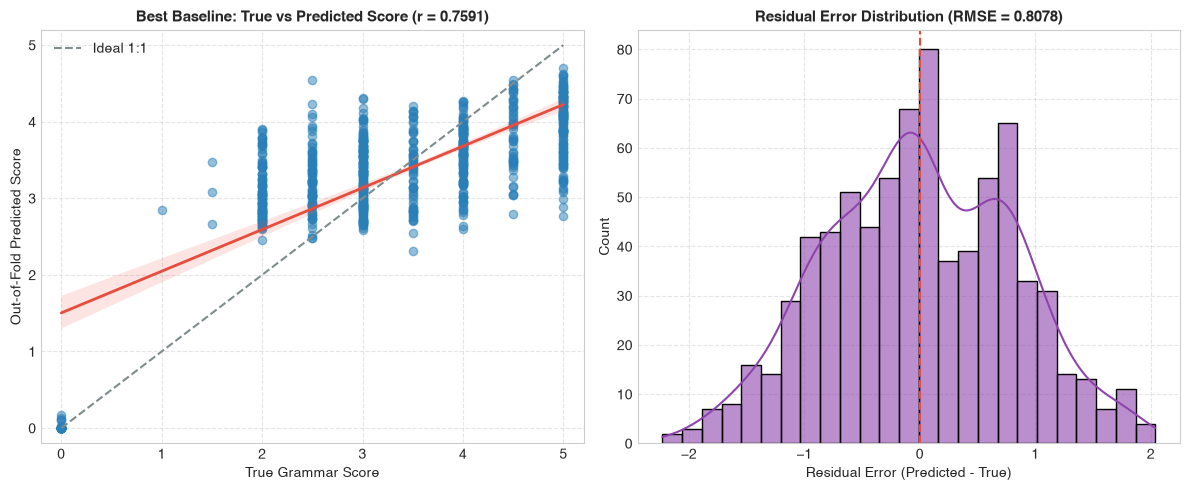

In [16]:
# Best baseline OOF predictions
best_oof = res_rf['oof_preds']
residuals = best_oof - y_true

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100)

# Visualization 5: Actual vs Predicted
sns.regplot(x=y_true, y=best_oof, ax=axes[0],
            scatter_kws={'alpha': 0.5, 'color': '#2980b9'},
            line_kws={'color': '#e74c3c', 'linewidth': 2})
axes[0].plot([0, 5], [0, 5], '--', color='#7f8c8d', linewidth=1.5, label='Ideal 1:1')
axes[0].set_title(f"Best Baseline: True vs Predicted Score (r = {res_rf['oof_pearson']:.4f})", fontsize=11, fontweight='bold')
axes[0].set_xlabel("True Grammar Score", fontsize=10)
axes[0].set_ylabel("Out-of-Fold Predicted Score", fontsize=10)
axes[0].set_xlim(-0.2, 5.2)
axes[0].set_ylim(-0.2, 5.2)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Visualization 6: Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[1], color='#8e44ad', bins=25, alpha=0.6)
axes[1].axvline(0, color='#e74c3c', linestyle='--', linewidth=1.5)
axes[1].set_title(f"Residual Error Distribution (RMSE = {res_rf['oof_rmse']:.4f})", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Residual Error (Predicted - True)", fontsize=10)
axes[1].set_ylabel("Count", fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


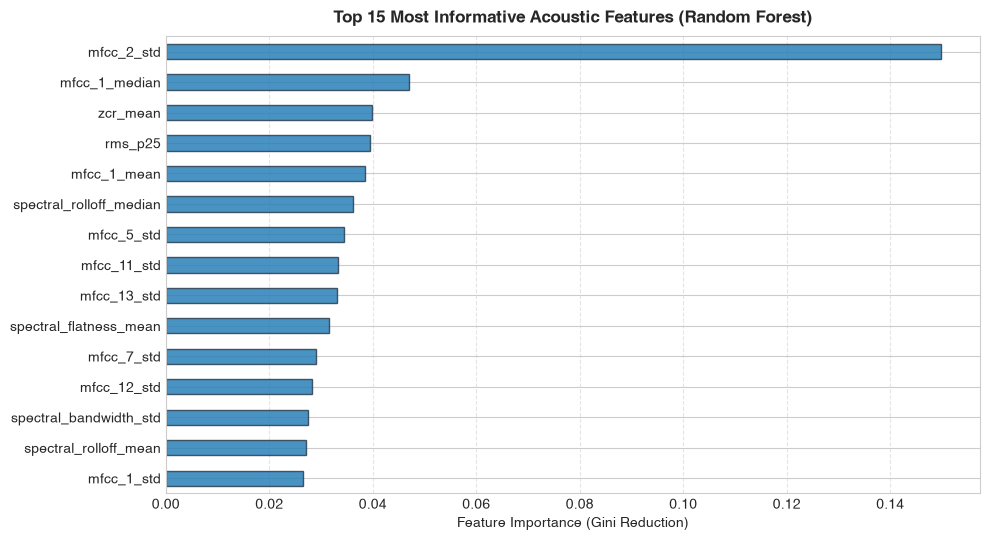

In [17]:
# Visualization 7: Top Acoustic Feature Importances
# Fit Random Forest on all training data to inspect feature importances
full_rf = get_audio_rf()
full_rf.fit(X_audio, y_true)

importances = pd.Series(full_rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=100)
colors = ['#16a085' if any(w in feat for w in ['pause', 'silence', 'speech']) else '#2980b9' for feat in importances.index]
importances.sort_values().plot(kind='barh', ax=ax, color=colors, edgecolor='#2c3e50', alpha=0.85)

ax.set_title("Top 15 Most Informative Acoustic Features (Random Forest)", fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel("Feature Importance (Gini Reduction)", fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 8. Baseline Experiment Summary Table

All baseline models evaluated under the exact same 5-fold stratified cross-validation protocol:


In [18]:
summary_table = tracker.df[['experiment_id', 'features', 'model', 'cv_rmse_mean', 'cv_pearson_mean', 'oof_rmse', 'oof_pearson', 'train_rmse', 'notes']]
display(summary_table)


,experiment_id,features,model,cv_rmse_mean,cv_pearson_mean,oof_rmse,oof_pearson,train_rmse,notes
0,EXP-01-MEAN,None,MeanPredictor,1.2382,0.0000,1.2383,-0.0162,1.2382,Reference floor baseline
1,EXP-02-DUR,Duration,Ridge(alpha=1.0),1.2344,0.0849,1.2344,0.0786,1.2334,Diagnostic audio duration baseline
2,EXP-03-AUDIO-RIDGE,Handcrafted Acoustic (75),Ridge(alpha=50),0.8199,0.7500,0.8203,0.7491,0.7702,Linear L2 regularized acoustic model
3,EXP-04-AUDIO-RF,Handcrafted Acoustic (75),RandomForest(depth=6),0.8074,0.7591,0.8078,0.7591,0.5840,Non-linear tree ensemble on acoustics
4,EXP-05-AUDIO-LGBM,Handcrafted Acoustic (75),LightGBM,0.8658,0.7298,0.8661,0.7297,0.7746,Gradient boosted trees on acoustics


## 9. Interpretation: What Did We Learn?

### Key Findings from Phase 1 & 2 Experiments:

1. **Duration Alone Contains Negligible Grammar Signal ($r = 0.0786$)**:
   Audio recording duration achieved virtually no correlation with grammar scores. Simply speaking longer does not indicate better grammar.

2. **Handcrafted Acoustics Provide a Strong Fluency Signal ($r pprox 0.759$, RMSE drops to 0.807)**:
   Extracting 75 acoustic features produced a dramatic improvement over the mean baseline (RMSE: $1.238 	o 0.808$, Pearson: $0.0 	o 0.759$).
   * **Most Informative Features**:
     * **Pause & Silence Dynamics** (`silence_ratio`, `num_pauses`, `active_speech_duration`, `mean_pause_duration`). Hesitation patterns and prolonged pauses correlate heavily with grammatical stumbling and disfluency.
     * **Spectral Energy & Stability** (`spectral_centroid`, `spectral_rolloff`, `rms_std`). Reflects vocal stability and acoustic clarity.
     * **MFCC coefficients** (MFCC 1, 2, 4). Captures spectral envelope and phoneme distribution.

3. **Inherent Limitations of Acoustic-Only Modeling**:
   * **Grammar vs Acoustic Fluency**: A speaker can speak fluently and confidently while using grammatically flawed syntax (e.g., incorrect verb tenses or subject-verb disagreement). Conversely, a native speaker might pause thoughtfully while constructing complex, grammatically flawless sentences.
   * **Prediction Compression**: Notice in the True vs. Predicted scatter plot that the acoustic model compresses predictions toward the mean (predicting values around 2.0 to 4.5, struggling to distinguish extreme 0.0 or 5.0 scores).

---

## 10. Recommendation for Phase 3: Speech-to-Text & Linguistic Features

Because the competition target is specifically **Grammar Scoring**, acoustic features have reached their theoretical ceiling. 

In **Phase 3**, we will incorporate:
1. **Whisper Speech-to-Text (ASR)**: Generate precise word-level transcripts for all recordings.
2. **Linguistic Feature Engineering**:
   * Lexical richness (Type-Token Ratio, vocd, vocabulary size).
   * Speech rate (words per minute).
   * Disfluency markers ("um", "uh", repetitions, false starts).
   * Part-of-Speech (POS) distribution, clause complexity, and syntactic parse tree depth.
   * Grammatical error detectors and language-model perplexity estimates.
